In [16]:
import pandas as pd

food_group_paths = [
    "../data/FOOD-DATA-GROUP1.csv",
    "../data/FOOD-DATA-GROUP2.csv",
    "../data/FOOD-DATA-GROUP3.csv",
    "../data/FOOD-DATA-GROUP4.csv",
    "../data/FOOD-DATA-GROUP5.csv",
]

food_groups = [pd.read_csv(path) for path in food_group_paths]
recipes = pd.concat(food_groups, ignore_index=True)

calories = pd.read_csv("../data/calories.csv")
ingredients = pd.read_csv("../data/Detail ingredient.csv")
nutrition_1 = pd.read_csv("../data/Food Nutri.csv")
nutrition_2 = pd.read_csv("../data/Food Nutri 2.csv")
diet_recommendations = pd.read_csv("../data/Personalized_Diet_Recommendations.csv")

## Phase 1: Data Selection & EDA for Welly

โฟกัสคอลัมน์สำคัญสำหรับ Nutrition Monitoring และความเสี่ยง NCDs พร้อมกราฟสำหรับการนำเสนอผู้สนับสนุน

Rows before: 2395 | after clean: 2395


,food,Caloric Value,Fat,Saturated Fats,Carbohydrates,Sugars,Protein,Cholesterol,Sodium,Nutrition Density
0,cream cheese,51,5.0,2.9,0.8,0.500,0.9,14.6,0.016,7.070
1,neufchatel cheese,215,19.4,10.9,3.1,2.700,7.8,62.9,0.300,130.100
2,requeijao cremoso light catupiry,49,3.6,2.3,0.9,3.400,0.8,0.0,0.000,5.400
3,ricotta cheese,30,2.0,1.3,1.5,0.091,1.5,9.8,0.017,5.196
4,cream cheese low fat,30,2.3,1.4,1.2,0.900,1.2,8.1,0.046,27.007


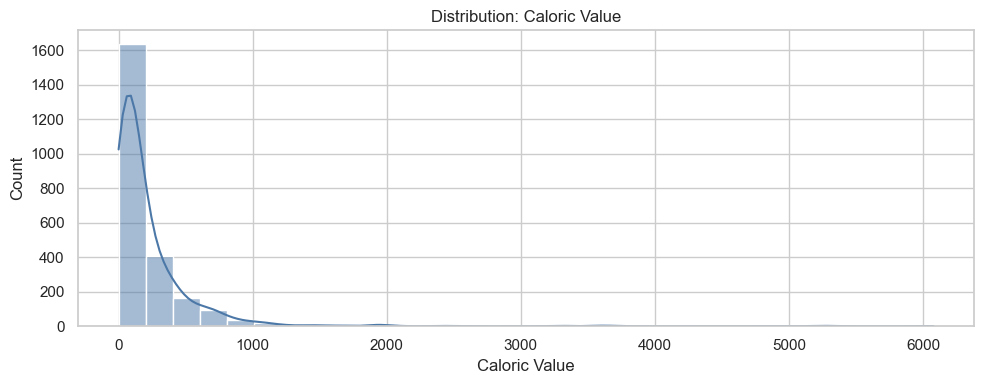

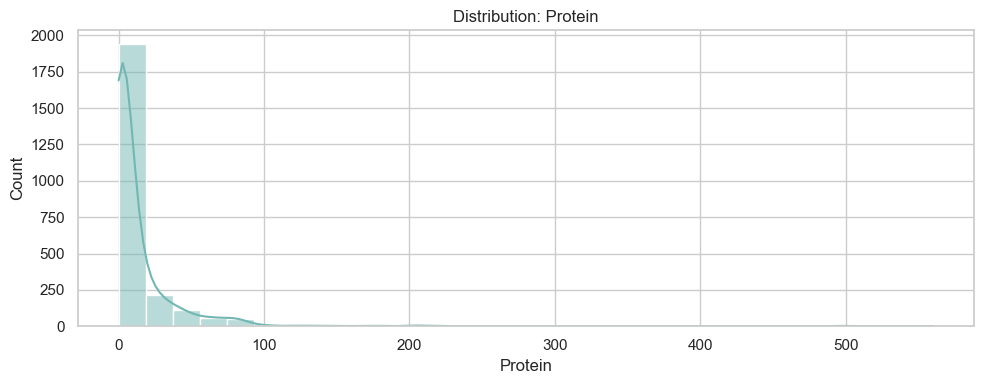

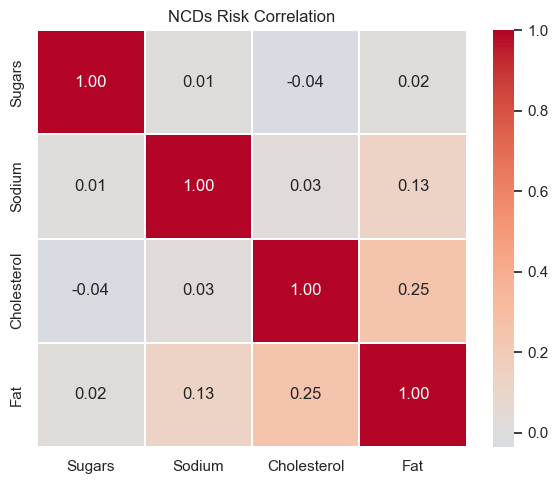

,food,Sodium
1943,adobo fresco,49.4
1047,salt,7.0
389,salt mackerel,6.1
370,jellyfish dried,5.6
1219,corned beef raw,5.5
1393,pork feet pickled,4.3
1382,pork blade roll roasted,3.7
854,white rice pasta raw,3.0
707,banana cream pie,2.8
848,rice pilaf raw,2.7


,food,Sugars
622,vanilla frosting,291.5
1466,danone low fat alsafi,255.0
707,banana cream pie,143.0
1968,cranberry sauce sweetened,105.0
2345,sweet potato canned,98.3
980,golden raisins,97.7
982,zante currants dried,96.9
746,chocolate semisweet,91.6
619,saccharin sweetener,85.2
632,almond paste,82.3


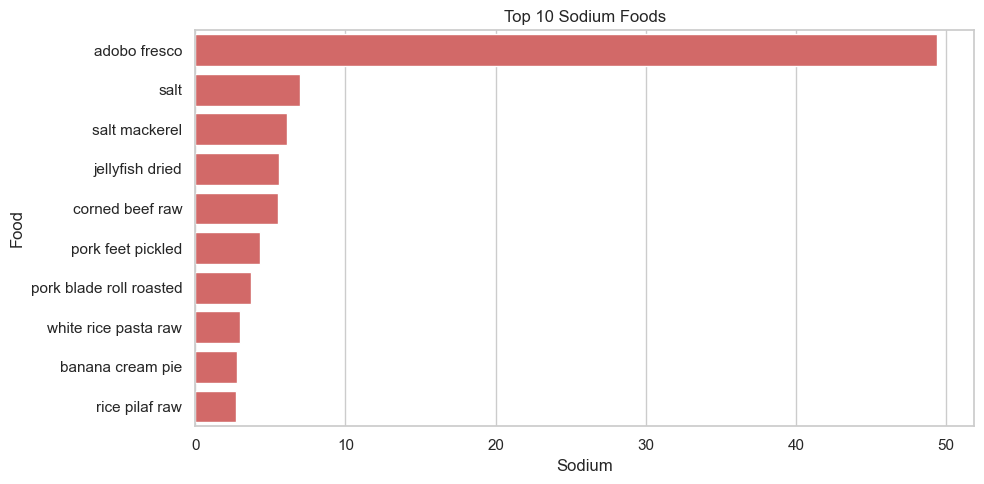

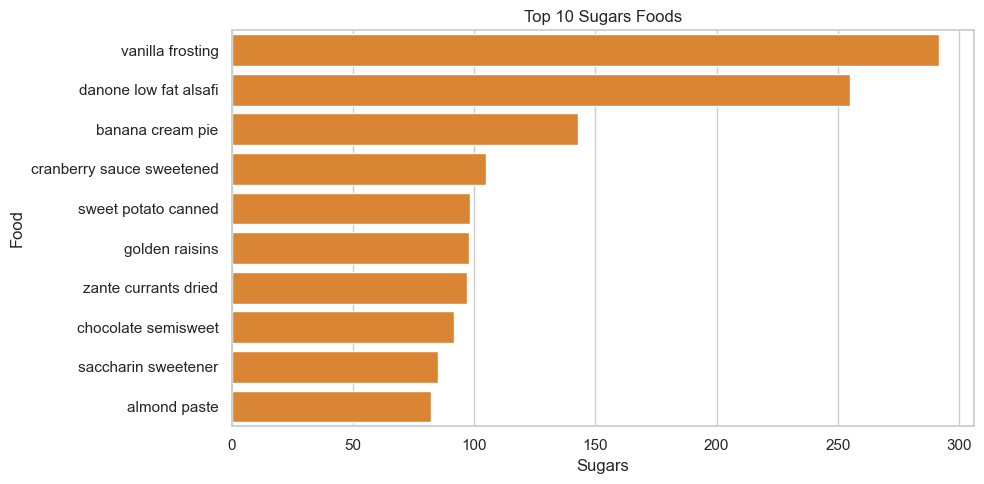

In [17]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

# Task 1) Data Selection & Preparation
required_cols = [
    "food",
    "Caloric Value",
    "Fat",
    "Saturated Fats",
    "Carbohydrates",
    "Sugars",
    "Protein",
    "Cholesterol",
    "Sodium",
    "Nutrition Density",
]

def match_required_columns(df, required):
    available = list(df.columns)
    lower_map = {str(c).strip().lower(): c for c in available}
    matched = {}
    missing = []
    for col in required:
        key = str(col).strip().lower()
        if key in lower_map:
            matched[col] = lower_map[key]
        else:
            missing.append(col)
    return matched, missing

combined = pd.concat(food_groups, ignore_index=True)
col_map, missing_cols = match_required_columns(combined, required_cols)

if missing_cols:
    print("Missing required columns:", missing_cols)

phase1_df = combined[list(col_map.values())].rename(columns={v: k for k, v in col_map.items()})

# Convert numeric columns and handle missing values
numeric_cols = [c for c in required_cols if c != "food"]
for c in numeric_cols:
    if c in phase1_df.columns:
        phase1_df[c] = pd.to_numeric(phase1_df[c], errors="coerce")

before_rows = len(phase1_df)
phase1_df = phase1_df.drop_duplicates()
phase1_df = phase1_df.dropna(subset=[c for c in required_cols if c in phase1_df.columns])
after_rows = len(phase1_df)

print(f"Rows before: {before_rows} | after clean: {after_rows}")
display(phase1_df.head())

# Task 2) EDA for Sponsorship
plt.figure(figsize=(10, 4))
if sns is not None:
    sns.histplot(phase1_df["Caloric Value"], bins=30, kde=True, color="#4C78A8")
else:
    plt.hist(phase1_df["Caloric Value"], bins=30, color="#4C78A8", edgecolor="white")
plt.title("Distribution: Caloric Value")
plt.xlabel("Caloric Value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
if sns is not None:
    sns.histplot(phase1_df["Protein"], bins=30, kde=True, color="#72B7B2")
else:
    plt.hist(phase1_df["Protein"], bins=30, color="#72B7B2", edgecolor="white")
plt.title("Distribution: Protein")
plt.xlabel("Protein")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

corr_cols = ["Sugars", "Sodium", "Cholesterol", "Fat"]
corr_df = phase1_df[corr_cols].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(6, 5))
if sns is not None:
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, annot=True, fmt=".2f")
else:
    plt.imshow(corr, cmap="coolwarm", aspect="auto")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
plt.title("NCDs Risk Correlation")
plt.tight_layout()
plt.show()

top_sodium = phase1_df.sort_values("Sodium", ascending=False).head(10)
top_sugars = phase1_df.sort_values("Sugars", ascending=False).head(10)

display(top_sodium[["food", "Sodium"]])
display(top_sugars[["food", "Sugars"]])

plt.figure(figsize=(10, 5))
if sns is not None:
    sns.barplot(data=top_sodium, x="Sodium", y="food", color="#E45756")
else:
    plt.barh(top_sodium["food"], top_sodium["Sodium"], color="#E45756")
    plt.gca().invert_yaxis()
plt.title("Top 10 Sodium Foods")
plt.xlabel("Sodium")
plt.ylabel("Food")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
if sns is not None:
    sns.barplot(data=top_sugars, x="Sugars", y="food", color="#F58518")
else:
    plt.barh(top_sugars["food"], top_sugars["Sugars"], color="#F58518")
    plt.gca().invert_yaxis()
plt.title("Top 10 Sugars Foods")
plt.xlabel("Sugars")
plt.ylabel("Food")
plt.tight_layout()
plt.show()

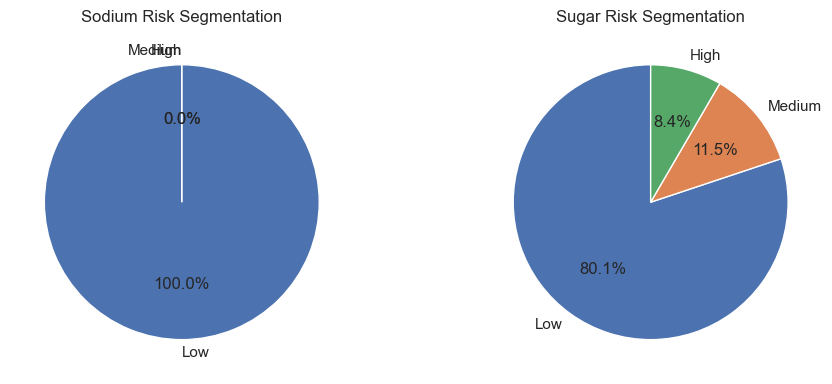

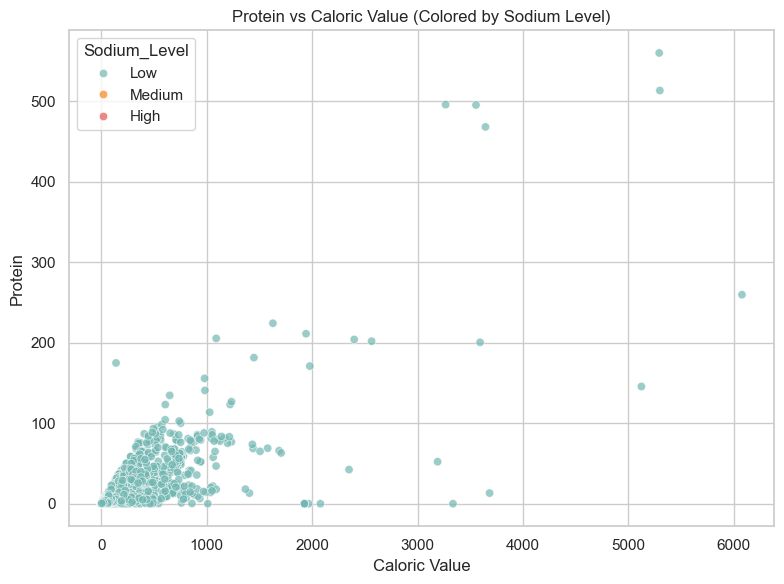

,food,Protein,Caloric Value,Sodium_Level
360,whiting cooked,16.9,84,Low
467,whiting raw,16.8,83,Low
528,blue crab cooked,15.2,71,Low
375,cisco raw,15.0,77,Low
473,atlantic croaker raw,14.0,82,Low
516,whelk cooked,13.5,78,Low
397,scup cooked,12.1,68,Low
1315,turkey gizzard cooked,11.9,70,Low
385,spot cooked,11.9,79,Low
475,spot raw,11.8,79,Low


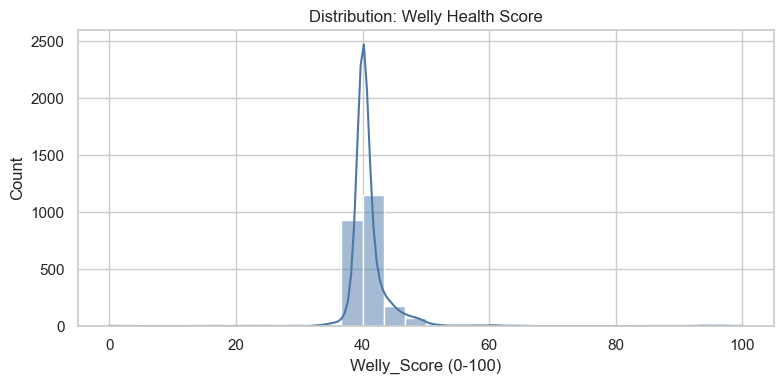

In [20]:
# Task 4) Deeper Insight from phase1_df
phase1_df = phase1_df.copy()

# 1) Risk Segmentation
sodium_g = phase1_df["Sodium"].copy()
if sodium_g.max() > 10:
    # Heuristic: assume mg if values are very large; convert to grams
    sodium_g = sodium_g / 1000.0
phase1_df["Sodium_g"] = sodium_g

phase1_df["Sodium_Level"] = pd.cut(
    phase1_df["Sodium_g"],
    bins=[-np.inf, 0.14, 0.4, np.inf],
    labels=["Low", "Medium", "High"],
)
phase1_df["Sugar_Level"] = pd.cut(
    phase1_df["Sugars"],
    bins=[-np.inf, 5, 15, np.inf],
    labels=["Low", "Medium", "High"],
)

sodium_counts = phase1_df["Sodium_Level"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0)
sugar_counts = phase1_df["Sugar_Level"].value_counts().reindex(["Low", "Medium", "High"]).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].pie(sodium_counts, labels=sodium_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Sodium Risk Segmentation")
axes[1].pie(sugar_counts, labels=sugar_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Sugar Risk Segmentation")
plt.tight_layout()
plt.show()

# 2) Efficiency Scatter Plot
plt.figure(figsize=(8, 6))
if sns is not None:
    sns.scatterplot(
        data=phase1_df,
        x="Caloric Value",
        y="Protein",
        hue="Sodium_Level",
        alpha=0.7,
        palette={"Low": "#72B7B2", "Medium": "#F58518", "High": "#E45756"},
    )
else:
    for level, color in [("Low", "#72B7B2"), ("Medium", "#F58518"), ("High", "#E45756")]:
        subset = phase1_df[phase1_df["Sodium_Level"] == level]
        plt.scatter(subset["Caloric Value"], subset["Protein"], s=12, alpha=0.7, color=color, label=level)
    plt.legend()
plt.title("Protein vs Caloric Value (Colored by Sodium Level)")
plt.xlabel("Caloric Value")
plt.ylabel("Protein")
plt.tight_layout()
plt.show()

# Identify High Protein & Low Calorie (Superfood candidates)
candidate_df = phase1_df.dropna(subset=["Protein", "Caloric Value"]).copy()
protein_thresh = candidate_df["Protein"].quantile(0.75)
calorie_thresh = candidate_df["Caloric Value"].quantile(0.25)
superfoods = candidate_df[
    (candidate_df["Protein"] >= protein_thresh)
    & (candidate_df["Caloric Value"] <= calorie_thresh)
].copy()

# If too strict, relax the thresholds a bit
if superfoods.empty:
    protein_thresh = candidate_df["Protein"].quantile(0.6)
    calorie_thresh = candidate_df["Caloric Value"].quantile(0.4)
    superfoods = candidate_df[
        (candidate_df["Protein"] >= protein_thresh)
        & (candidate_df["Caloric Value"] <= calorie_thresh)
    ].copy()

superfoods = superfoods.sort_values(["Protein", "Caloric Value"], ascending=[False, True])
display(superfoods[["food", "Protein", "Caloric Value", "Sodium_Level"]].head(15))

# 3) Welly Health Score
phase1_df["Welly_Score_raw"] = (phase1_df["Protein"] * 2) - (
    phase1_df["Sugars"] + phase1_df["Sodium_g"] + phase1_df["Saturated Fats"]
)
score_min = phase1_df["Welly_Score_raw"].min()
score_max = phase1_df["Welly_Score_raw"].max()
if score_max > score_min:
    phase1_df["Welly_Score"] = (phase1_df["Welly_Score_raw"] - score_min) / (score_max - score_min) * 100
else:
    phase1_df["Welly_Score"] = 50

plt.figure(figsize=(8, 4))
if sns is not None:
    sns.histplot(phase1_df["Welly_Score"], bins=30, kde=True, color="#4C78A8")
else:
    plt.hist(phase1_df["Welly_Score"], bins=30, color="#4C78A8", edgecolor="white")
plt.title("Distribution: Welly Health Score")
plt.xlabel("Welly_Score (0-100)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Executive Summary 
- ฐานข้อมูลอาหารครอบคลุมช่วงพลังงานและโปรตีนหลากหลาย ทำให้ระบบ Welly สามารถวิเคราะห์พฤติกรรมการกินได้ทั้งกลุ่มสุขภาพดีและกลุ่มเสี่ยง NCDs
- ความสัมพันธ์ระหว่างน้ำตาล โซเดียม คอเลสเตอรอล และไขมันชี้ให้เห็นว่าเมนูความเสี่ยงสูงสามารถถูกคัดกรองและแจ้งเตือนแบบเชิงรุกได้
- รายการอาหารโซเดียมและน้ำตาลสูงสุดช่วยเป็นกรณีศึกษาในการออกแบบข้อความเตือนและคำแนะนำที่ปรับให้เหมาะกับคนไทย เพื่อช่วยลดพฤติกรรมเสี่ยงในชีวิตประจำวัน